## 1. Introduction

This project aims to better understand how a market maker may set their bid and ask quotes on electronic limit order markets. More specifically, we look into how a market maker is able to detect a regime change in the order book. Market makers are exposed to adverse selection; to manage their risks appropriately, they need to re-adjust their bid-ask quotes and their inventory to ensure their quotes and inventory proportions are adhering to their trading strategy and their risk appetite. The problem is not only how to react, but also when to react; this difficulty arises due to the limitations of what the market maker can observe — there is no publicly shared data directly telling the market maker how to differentiate between a sequence of orders placed on the market due to market noise versus one that is placed due to informed buying, for example. *Note: informed buying or selling is only one cause (among perhaps many) resulting in order flow regime change. This project examines regime changes in general. Detecting a regime change and understanding the reason is not within the scope of this project (for now).* The aim of this project is to explore how a market maker may distinguish between noise and a regime change within order flows. 

We start with a simple toy model that aims to provide intuition behind the problem. Specifically, this model will help to build a basic understanding of why detecting a regime change is difficult, and how the parameters in the model interact. 

## 2. Toy-problem

### 2.1 Problem context and set up

Given past history of order flow, how are we — as a market maker — able to detect a regime change? For example, how can we tell the difference between noisy order flows vs. informed flow? 

We can start with a toy problem. First, let us represent each buy and sell as the i.i.d. random variable $X_i$. $X_i$ can be interpreted as the signed trade of the $i$-th trade; it tells us the direction and quantity of the $i$-th trade.

$$ 
X_i = \begin{cases}
    +1 &i\text{-th trade} \text{ is a buy of 1 unit} \\
    -1 &i\text{-th trade} \text{ is a sell of 1 unit}
\end{cases}
$$

where $i = 1, 2, ...$. Then the cumulative order flow is $S_n = \sum_{i=1}^n X_i$ and is interpreted as the net signed order flow after $n$ trades.

We also define the probability that a certain trade is a buy or a sell. Let $\mathbb{P}(\text{trade } i \text{ is a buy}) = p$, and $\mathbb{P}(\text{trade } i \text{ is a sell}) = q = 1-p$. Notice that these probabilities are independent of time, hence in this section we refer to $p$ simply as the probability of a buy and $q$ as the probability of a sell. Now, since the probability of a sell completely depends on the probability of a buy, we need only consider the probability of a buy, $p$, to characterise our model.  
Symmetric probabilities of $p = q = 0.5$ gives us no buy or sell bias, whereas $p > 0.5$ and $p < 0.5$ represent a market that has a buy/sell bias respectively. Bias in this context just means that the probability of any trade is more likely to be either a buy or a sell. In this simple model, varying the probability of a buy $p$ can be interpreted as changing the market regime structure. **maybe add some research on this, e.g. bullish market more buys occur, this can correspond to $p > 0.5$**


In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

def cum_ord_flow(n, p):
    """
    Inputs:
    n: number of trades
    p: probability of buy (independent of time)

    Outputs: 
    X = signed trade 
    S = cumulative order flow after n trades
    """

    # probability must be between 0 and 1
    if not 0 <= p <= 1:
        raise ValueError("p must be between 0 and 1.")

    # X_i
    X = np.random.choice([-1, 1], size = n-1, p = [1-p, p])

    # cumulative order flow
    S = np.zeros(n)

    for i in range(n-1):
        S[i+1] = S[i] + X[i]

    return X, S

### 2.2 Simple qualitative exploration using symmetric probabilities for fixed $n$

To explore our toy model, we begin by assuming symmetric probabilities, that is, letting $p = q = 0.5$. We now want to see how the cumulative order flow behaves using $n = 10,000$ trades/steps. Under these probabilities, the cumulative order flow $S_n$ is a symmetric random walk. 

We first explore by simulating $N = 10$ different sample paths to qualitatively understand the variability of cumulative order flow given the same market structure (i.e. under fixed probability). 

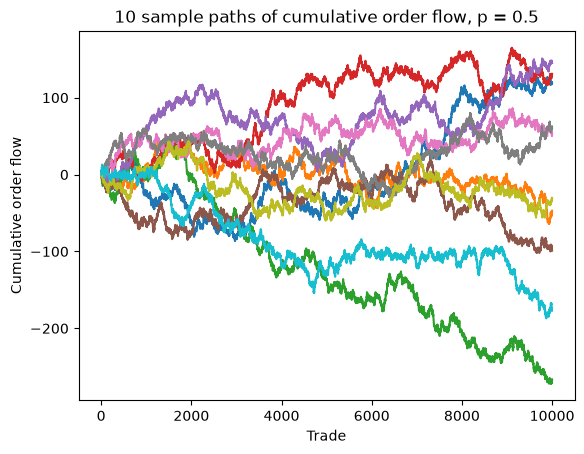

In [2]:
# cumulative order flow simulation under equal probabilities and n = 10000 steps
n = 10**4
p = 0.5

# plotting N = 10 different sample paths
N = 10
for i in range(N):
    # cumulative sample paths
    X, S = cum_ord_flow(n = n, p = p)
    plt.plot(np.arange(n), S)

# plotting cumulative order flow
plt.title(f"10 sample paths of cumulative order flow, p = {p}")
plt.xlabel("Trade")
plt.ylabel("Cumulative order flow")
plt.show()

We can run the above code many times and observe that the 10 sample paths generate variable paths. For some runs, the majority of the paths have negative cumulative order flow whereas for other runs, the signs cumulative order flow quite evenly spread throughout. If cumulative order flow is truly noise with symmetric probabilities (under $n = 10,000$ trades), the sample paths can vary substantially. As a result, it will be difficult to tell the difference between noise and structural change as large cumulative imbalances can arise from noise, as seen in the simulation.

Now we use larger $N = 1,000$ to explore the empirical distribution of the terminal value of our cumulative order flow under the same, fixed $p = 0.5$ and $n = 10,000$. We'll also plot the theoretical distribution which is derived below for some arbitrary $p \in [0,1]$.

Recall the i.i.d random variable $X_i$ is

$$ 
X_i = \begin{cases}
    +1 &\mathbb{P}(i\text{-th trade} \text{ is a buy of 1 unit}) = p \\
    -1 &\mathbb{P}(i\text{-th trade} \text{ is a sell of 1 unit}) = 1 - p
\end{cases}
$$

Then the first moment is, 

\begin{align*}
    \mathbb{E}(X_i) 
        &= 1 \cdot p + (-1) \cdot (1 - p) \\
        &= 2p - 1
\end{align*}

We also have the second moment 

\begin{align*}
    \mathbb{E}(X_i^2) 
        &= (1)^2 \cdot p + (-1)^2 \cdot (1-p) \\
        &= 1
\end{align*}

Therefore the variance is 

\begin{align*}
    \mathbb{V}\text{ar}(X_i) 
        &= \mathbb{E}(X_i^2) - \mathbb{E}(X_i)^2 \\
        &= 1 - (2p - 1)^2 \\ 
        &= -4p^2 + 4p \\
        &= 4p(1 - p)
\end{align*}

Also $S_n = \sum_{i=1}^n X_i$. By linearity and identicalness, 

$$\mathbb{E}(S_n^{(j)}) = n(2p-1) \text{ and } \mathbb{V}\text{ar}(S_n^{(j)}) = 4np(1-p)$$

for all $j = 1, 2, ..., N$.

For large $n$, by the Central Limit Theorem, $S_n^{(j)} \sim \mathcal{N}(n(2p-1), 4np(1-p))$ approximately. 

Note that the variance is maximised when $p = 0.5$. The use of any other probabilities $p \in [0,1]$ will lead to variance lower than $4np(1-p) = 4n \cdot \frac{1}{2} \cdot \frac{1}{2} = 4n$. 

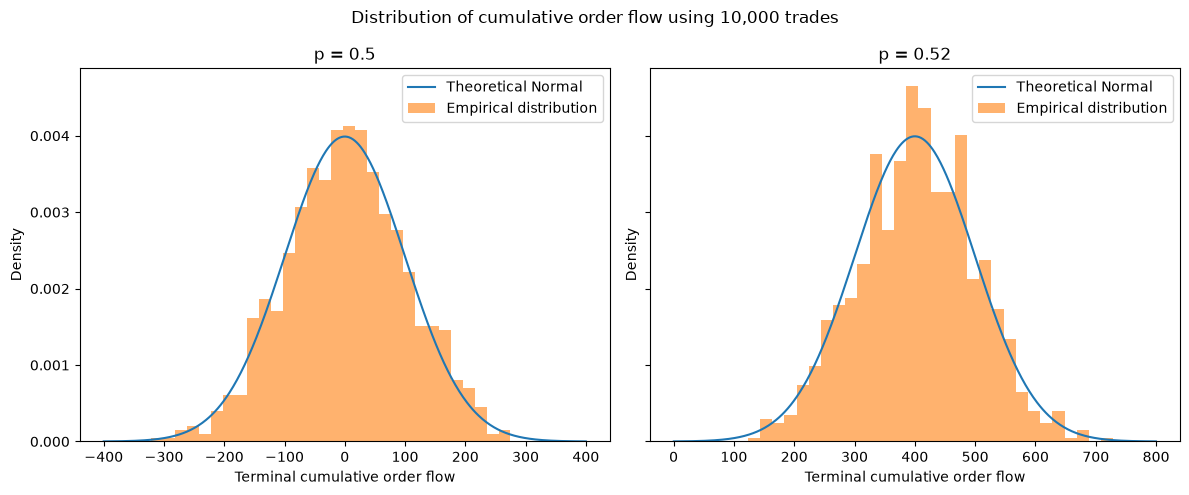

In [3]:
# library
from scipy.stats import norm

#  function that plots distribution of terminal values
def plot_terminal_distribution(N, n, p, ax, bins = 30):
    """
    Inputs:
    N: number of sample paths
    n: number of trades
    p: probability of a buy
    ax: subplot to plot on
    bins: number of histogram bins

    Outputs:
    Plots distribution of cumulative order flow terminal values 
    """

    # empirical distribution of terminal values
    term_values = np.zeros(N)

    for i in range(N):
        # cumulative sample paths
        term_values[i] = cum_ord_flow(n = n, p = p)[1][-1]

    # theoretical normal statistics
    mu = n * (2 * p - 1)
    sigma = np.sqrt(4 * n * p * (1 - p))

    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
    y = norm.pdf(x, loc = mu, scale = sigma)

    # plotting

    # normal distribution
    ax.plot(x, y, label = "Theoretical Normal")

    # empirical distribution
    ax.hist(term_values, bins = bins, density = True, alpha = 0.6, label = "Empirical distribution")

    ax.set_title(f"p = {p}")
    ax.set_xlabel("Terminal cumulative order flow")
    ax.set_ylabel("Density")
    ax.legend()

# plotting using N = 1000, n = 10000, p = 0.5 and 0.52
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharey = True)

plot_terminal_distribution(N = 1000, n = 10000, p = 0.5, ax = axes[0])
plot_terminal_distribution(N = 1000, n = 10000, p = 0.52, ax = axes[1])

fig.suptitle("Distribution of cumulative order flow using 10,000 trades")

plt.tight_layout()
plt.show()

There is quite a lot of variability between the individual sample paths as seen in the previous plot. Despite this, when we look at the terminal values across many paths, they are approximately normally distributed around 0 (left histogram). This shows that a path can have periods of quite strong buying or selling even when there is no actual bias in the underlying order flow (i.e. when $p = 0.5$). So if we observe what looks like strong buying, this alone isn't enough to say that a structural change has occured — it could just be noise from a symmetric order flow process. 

Comparing the theoretical distributions of terminal cumulative order flow for $n = 10,000$ and $p = 0.5$ vs. $p = 0.52$, we get $\mathcal{N}(0, 100)$ and $\mathcal{N}(400, 99.84)$ respectively. The main difference between the two theoretical distributions is the mean. We expect (on average) that a model representing a market with a stronger buy-side bias will have higher terminal cumulative order flow compared to a model with no bias (i.e. symmetric probability $p = 0.5$). This can be observed through the empirical distribution plots above. Both histograms have a similar bell-shape with relatively similar variance, however, their peak (mean) is concentrated about different values; 0 and 400 respectively. 

### 2.3 Varying probabilities $p$ with fixed $n$

We now start to explore what happens to our sample paths when we vary the probability $p$ using some fixed $n$. The values of $p$ are chosen to represent increasingly strong buy-side biases (i.e. $p \geq 0.5$). There is no need to consider sell-side biases as we can expect similar interpretation of outcomes due to the symmetric nature of our model, i.e. because $p = 1-q$. The same values will be used across each $n$ so that the effect of changing the number of observed trades can be compared directly. This will allow us to better understand how the model parameters interact. Despite being only a toy-problem, this exploration will give a stronger basic understanding of the problem, our model, and its moving parts. 


In [4]:
# function that plots the cumulative order flows using different N, n, and p
def plot_cum_order_flow(N, n, probs):
    """
    Inputs:
    N: number of sample paths
    n: number of trades
    probs: probabilities of a buy

    Outputs:
    2x2 plot of 10 sample paths under different probabilities
    """

    # cumulative order flow simulation under different probabilities

    fig, axes = plt.subplots(2, 2, figsize = (12, 8), sharex = True, sharey = True)

    # for different p
    for ax, p in zip(axes.flat, probs):

        # plotting N different sample paths for different values of p
        for i in range(N):

            # cumulative sample paths
            X, S = cum_ord_flow(n = n, p = p)

            ax.plot(np.arange(n), S)

        # plotting cumulative order flow
        ax.set_title(f"p = {p}")
        ax.set_xlabel("Trade")
        ax.set_ylabel("Cumulative order flow")

    fig.suptitle(f"{N} sample paths of cumulative order flow using {n} trades")

    plt.tight_layout()
    plt.show()

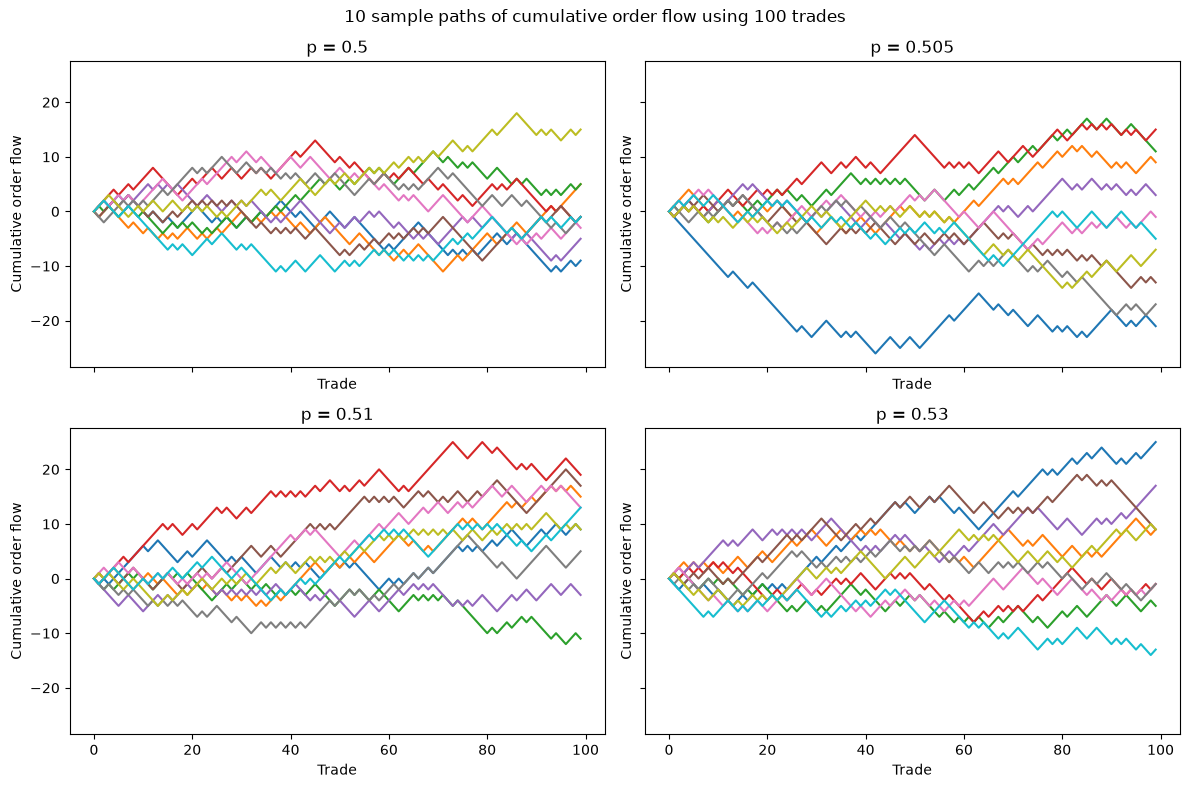

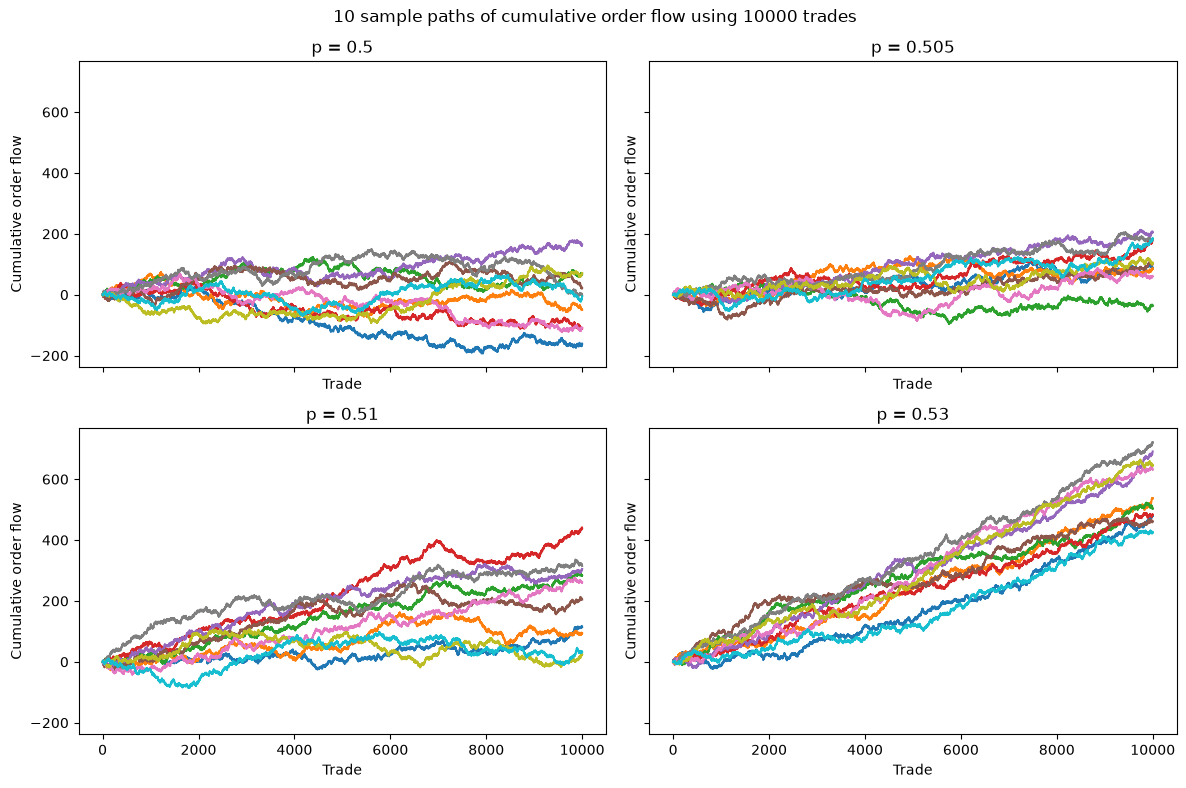

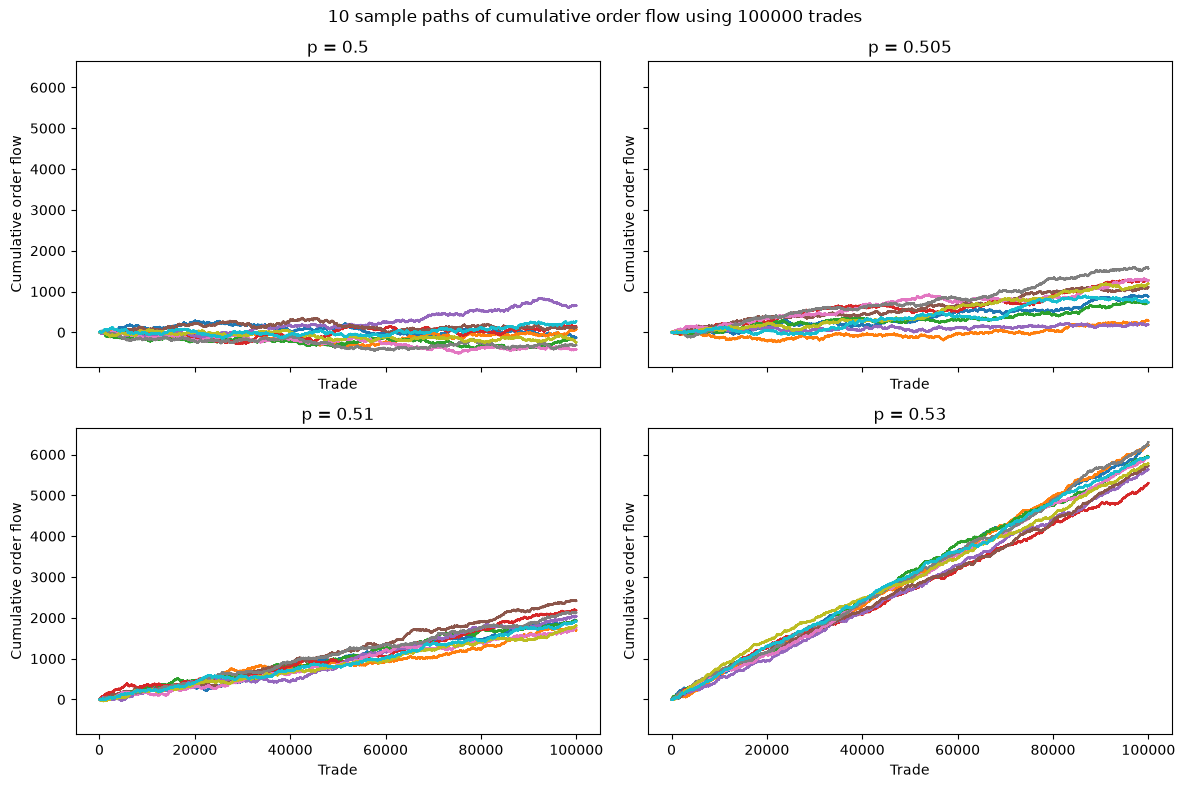

In [5]:
# same probabilities across n = 100, 1000, 10000 trades
probs = np.array([0.5, 0.505, 0.51, 0.53])

plot_cum_order_flow(N = 10, n = 10**2, probs = probs)
plot_cum_order_flow(N = 10, n = 10**4, probs = probs)
plot_cum_order_flow(N = 10, n = 10**5, probs = probs)

Despite keeping the buy-probabilities $p$ constant (across varying $n$) we observe different effects to the cumulative order flow for different values of $n$. For lower $n$, e.g. $n = 100$, it is difficult to distinguish between the sample paths under different buy probabilities. That is, the sample paths under symmetric probability $p = 0.5$ vs. under a buy-side bias with probability $p = 0.53$ look extremely similar as they have no distinguishing features. As $n$ increases, the sample paths under different probabilities start to become increasingly easier to distinguish. Take $n = 100,000$ for example: the sample paths with symmetric probability $p = 0.5$ looks relatively flat compared to when $p = 0.53$ where we observe an obvious increasing (and relatively linear) trend. The distinguishable characteristics between sample paths for any fixed $n$ start to become increasingly apparent and obvious as $n$ increases. We can explain this observation intuitively: for larger $n$ the buy-bias has a larger number of trades to compound over, and as $n$ increases, the compounding becomes more aggressive. As a result, the drift introduced in the model from the asymmetric probability compounds additively which we observe as a strong upward trend (that seems to be linear - note that mentioning linear trend may not add to the discussion as much as it seems, and claiming it is linear will have to be backed by proof, so it may not be even necessary to mention the trend is linear, or if we do, there needs to be a simple proof). 

### 2.4 Toy-problem takeaways and limitations

**Takeaways:**

A model with no buy-bias (i.e. symmetric probabilities) exhibits relatively high variance (in fact, variance is maximised at $p = \frac{1}{2}$) and can produce paths that display strong periods of buying. Hence, simply observing paths that have strong periods of buying isn't sufficient in concluding that the structure of the underlying order-flow process has changed. This observation highlights exactly why detecting a regime change is difficult; not only can variation in order flows occur between regimes, but variation can arise within certain regimes as well. 

**Limitations and extensions:**

A limitation that immediately follows from considering the parameters of the toy-model is the assumption that trades are independently and identically distributed. A simple example of why this isn't realistic is to consider a period of extreme strong selling. Large amounts of sell orders at lower-than-market price can cause a chain of selling frenzy. This is just a simple counter argument for this assumption; market dynamics are complex and even when the market's current regime isn't in an extreme state, dependence between trades can still be observed. One possible, more realistic implementation of idea may be to define the trades as being correlated, with the correlation parameter being dependent on the current state of the entire market. 

The cumulative order flow process is indexed over the trade number instead of time. Moving to calendar time would make the interpretation more natural and would lead to an additional modelling choice between discrete and continuous calendar time. Indexing by trade number strips information of when trades arrive; the current model conditions on the fact that a trade has occurred — the timing of that trade is discarded. After changing our index to calendar time, an additional extension would be to treat the trade arrivals as random. One simple approach is to model the number of trades as a Poisson process. The cumulative order flow would then be a compound Poisson process with continuous-time and discrete-space. 

The current toy model assumes that each trade observed is of 1 unit of the underlying asset. Of course, market participants are able to purchase or sell more than 1 unit per transaction. A straightfoward extension would be to introduce a random variable representing trade quantity, modelled using a chosen distribution. The choice of the distribution is itself a modelling decision, with many distributions being appropriate depending on the features and purpose of the eventual model. 

The entire purpose of this project is to examine the ways in which market makers are able to detect regime changes in the order flows. The toy model encodes different market regimes through the probability of a buy, but these probabilities are assumed to be constant throughout all trades. Hence, despite being able to vary $p$ *across* models to explicitly compare markets under different buying biases, the toy model is limited in providing intuition on how market structure can change over time; within a given path, there is no mechanism for the underlying structure to change. An extension would be to explicitly incorporate states (that represent varying market structures) into the model. An example would be a Markov chain, or more suited toward our project, a hidden Markov model. The latter is more directly tied to the problem as market makers aren't able to directly observe the underlying regime.  

Further extensions to the toy model are motivated by the sequential trade models discussed by Hasbrouck (2007). The models' aims are different to ours; it distinguishes between informed and uninformed traders within a market to model how a dealer's buy/sell probabilities evolve over time as trades arrive. Despite having a different aim, the features present in Hasbrouck's models that are absent in ours may be useful directions for potential model extensions. Hasbrouck distinguishes between informed and uninformed traders by considering some proportion of market participants $\mu$ to be the informed traders. Under this model, informed and uninformed traders behave differently, i.e. informed traders will always trade in the direction of their knowledge, and uninformed traders will trade in either direction randomly with some fixed probabilities. Despite its simplicity, this set up is not only intuitive, but provides economic structure to the model. Compared to the toy model, the introduction of trader heterogeneity in the sequential models results in a more realistic market dynamic. Relating this to our project objective, market regimes can change due to an increase in proportion of informed traders. The important caveat is that not all market regimes change due to informed trading. Hence, despite its advantages in modelling and intuition, distinguishing between informed and uninformed traders may be more specific than the problem at hand. 


- This mechanism allows the model to update market makers' prior beliefs (probability of buy and sell) given new flow of information

5. Model does not include any price information


The current model presents a number of limitations. Despite this, it is fit for its purpose. The toy model allowed an opportunity to study the behaviour of the cumulative order flow under a simple universe. This provided a strong intuition and a better understanding of why detecting regime changes is difficult and how the parameters of the toy model interact with each other. From there, the limitations give us additional direction for the ways in which we can improve our model, motivating the next section. This is all to say that the toy-model isn't perfect and anywhere close to answering our question, but it does give us a greater insight of the project problem. Acknowledging the model's limitations isn't to tick off a stage of the modelling process but rather to extend and discuss the model so that we can revise and iterate it.